# Homework 5 Problem 1: ViT vs. ResNet-18

**Course:** ECGR 4106  
**Student:** Gilberto Feliu  
**Student ID:** 801257813  
**Dataset:** CIFAR-100

This notebook reports the current Problem 1 experiment artifacts from `Results_Problem_1`. Problem 1 now has completed 10-epoch rows for all four ViT configurations and the ResNet-18 baseline.

## Experiment Setup

The custom Vision Transformer uses convolutional patch embedding, a learned class token, learned positional embeddings, `nn.TransformerEncoderLayer` blocks, layer normalization, and a linear classifier head for 100 CIFAR-100 classes. The ResNet-18 baseline uses `torchvision.models.resnet18(weights=None)` with the first convolution changed for 32 by 32 CIFAR images and the initial max-pooling layer removed.

All runs use CIFAR-100 normalization, Adam optimization, cross-entropy loss, batch size 64, and a 10-epoch schedule. The current CSV contains the completed 10-epoch Problem 1 results.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
RESULTS = ROOT / 'Results_Problem_1'
history_path = RESULTS / 'problem1_history.csv'
summary_path = RESULTS / 'problem1_summary.csv'
plot_path = RESULTS / 'problem1_loss_curves.png'
tradeoff_path = RESULTS / 'problem1_tradeoffs.png'
print('Summary:', summary_path)
print('History:', history_path)
print('Training plot:', plot_path)
print('Tradeoff plot:', tradeoff_path)

Summary: /home/gilberto/Homework_5/Results_Problem_1/problem1_summary.csv
History: /home/gilberto/Homework_5/Results_Problem_1/problem1_history.csv
Training plot: /home/gilberto/Homework_5/Results_Problem_1/problem1_loss_curves.png
Tradeoff plot: /home/gilberto/Homework_5/Results_Problem_1/problem1_tradeoffs.png


## Summary Results

The table below is read directly from `Results_Problem_1/problem1_summary.csv`. Every planned row includes completed 10-epoch training metrics, parameter counts, and FLOP estimates.

In [2]:
summary_df = pd.read_csv(summary_path, keep_default_na=False)
summary_df

,model_name,patch_size,embed_dim,depth,heads,mlp_dim,parameter_count,flops_forward,train_time_per_epoch_sec,final_train_loss,final_val_loss,test_accuracy_pct,notes
0,vit_patch4_dim256_d4_h4,4,256,4,4,1024,3214692,2.131507e+08,23.014994,3.325062,3.283429,20.01,device=cuda
1,vit_patch4_dim512_d8_h8,4,512,8,8,2048,25330276,1.670441e+09,106.715145,4.303222,4.323157,4.51,device=cuda
2,vit_patch8_dim256_d4_h4,8,256,4,4,1024,3239268,5.409485e+07,12.217159,3.902182,3.885059,9.68,device=cuda
3,vit_patch8_dim512_d8_h8,8,512,8,8,2048,25379428,4.302377e+08,42.299152,4.227836,4.269351,4.95,device=cuda
4,resnet18,,,,,,11220132,5.554688e+08,61.236564,1.048969,1.391882,61.20,device=cuda


## Clean Report Table

In [3]:
report_cols = [
    'model_name', 'parameter_count', 'flops_forward',
    'train_time_per_epoch_sec', 'final_val_loss', 'test_accuracy_pct', 'notes'
]
report_df = summary_df[report_cols].copy()
report_df.columns = ['Model', 'Params', 'FLOPs / Forward', 'Time / Epoch (s)', 'Final Val Loss', 'Test Accuracy (%)', 'Status']
report_df

,Model,Params,FLOPs / Forward,Time / Epoch (s),Final Val Loss,Test Accuracy (%),Status
0,vit_patch4_dim256_d4_h4,3214692,2.131507e+08,23.014994,3.283429,20.01,device=cuda
1,vit_patch4_dim512_d8_h8,25330276,1.670441e+09,106.715145,4.323157,4.51,device=cuda
2,vit_patch8_dim256_d4_h4,3239268,5.409485e+07,12.217159,3.885059,9.68,device=cuda
3,vit_patch8_dim512_d8_h8,25379428,4.302377e+08,42.299152,4.269351,4.95,device=cuda
4,resnet18,11220132,5.554688e+08,61.236564,1.391882,61.20,device=cuda


## Per-Epoch History

A full Problem 1 run should produce about 50 data rows: 5 models times 10 epochs. The current history file contains the completed Problem 1 runs.

In [4]:
history_df = pd.read_csv(history_path)
print(f'History rows: {len(history_df)}')
history_df

History rows: 50


,model_name,epoch,train_loss,val_loss,train_accuracy_pct,val_accuracy_pct,epoch_seconds
0,vit_patch4_dim256_d4_h4,1,4.010155,3.759034,7.828,11.36,23.015639
1,vit_patch4_dim256_d4_h4,2,3.738646,3.665595,11.850,13.50,22.786489
2,vit_patch4_dim256_d4_h4,3,3.640890,3.556376,13.436,14.62,22.918571
3,vit_patch4_dim256_d4_h4,4,3.606052,3.507664,14.038,16.03,23.130308
4,vit_patch4_dim256_d4_h4,5,3.554222,3.522711,14.900,16.13,23.087703
5,vit_patch4_dim256_d4_h4,6,3.535617,3.425678,15.396,17.34,22.934365
6,vit_patch4_dim256_d4_h4,7,3.436794,3.465146,17.226,17.02,22.914715
7,vit_patch4_dim256_d4_h4,8,3.438895,3.348804,17.018,18.73,23.025334
8,vit_patch4_dim256_d4_h4,9,3.347852,3.299602,18.770,19.72,23.194426
9,vit_patch4_dim256_d4_h4,10,3.325062,3.283429,19.102,20.01,23.141071


## Training and Tradeoff Figures

### Loss and Accuracy Curves

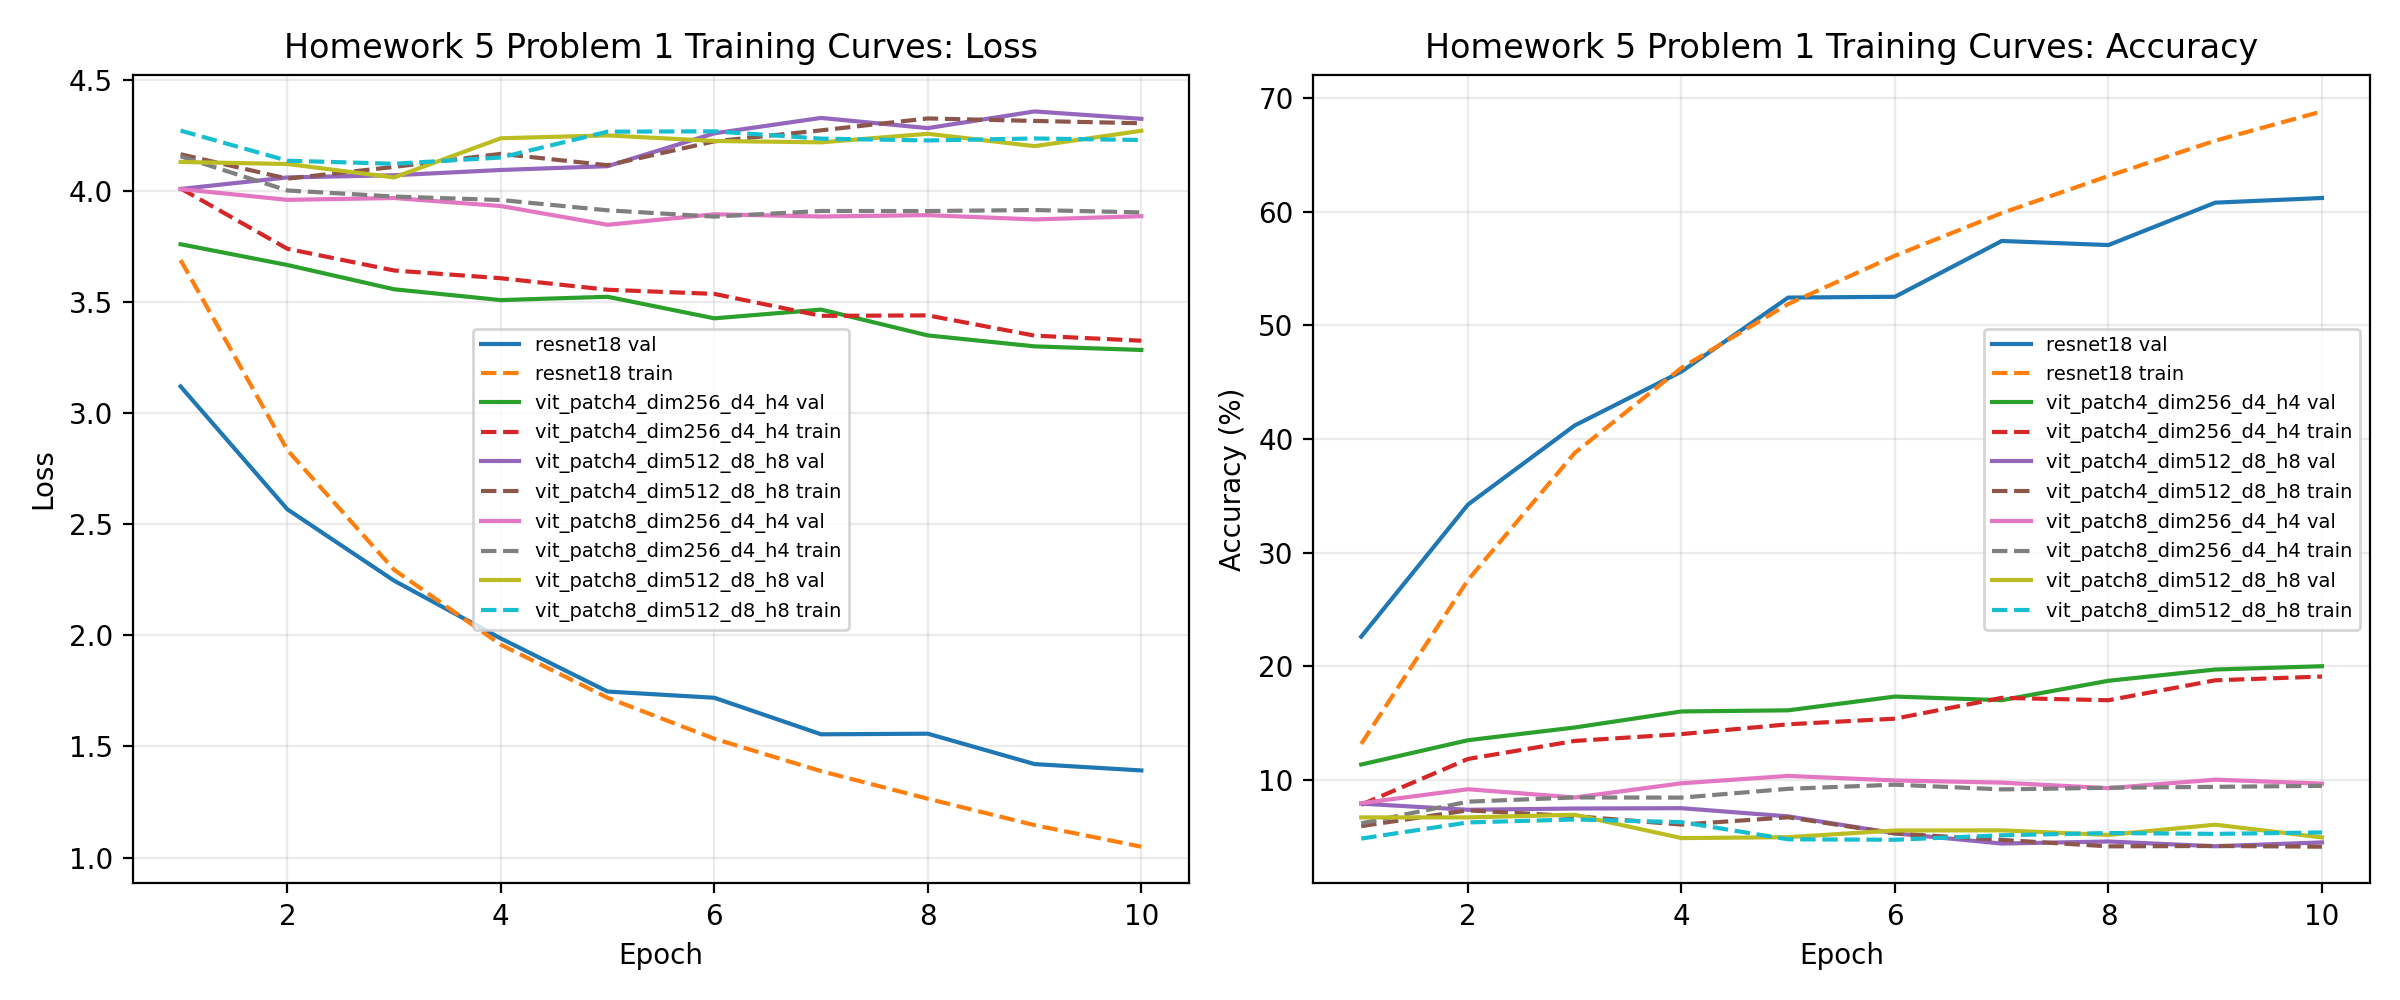

### Accuracy, Runtime, and Compute Tradeoffs

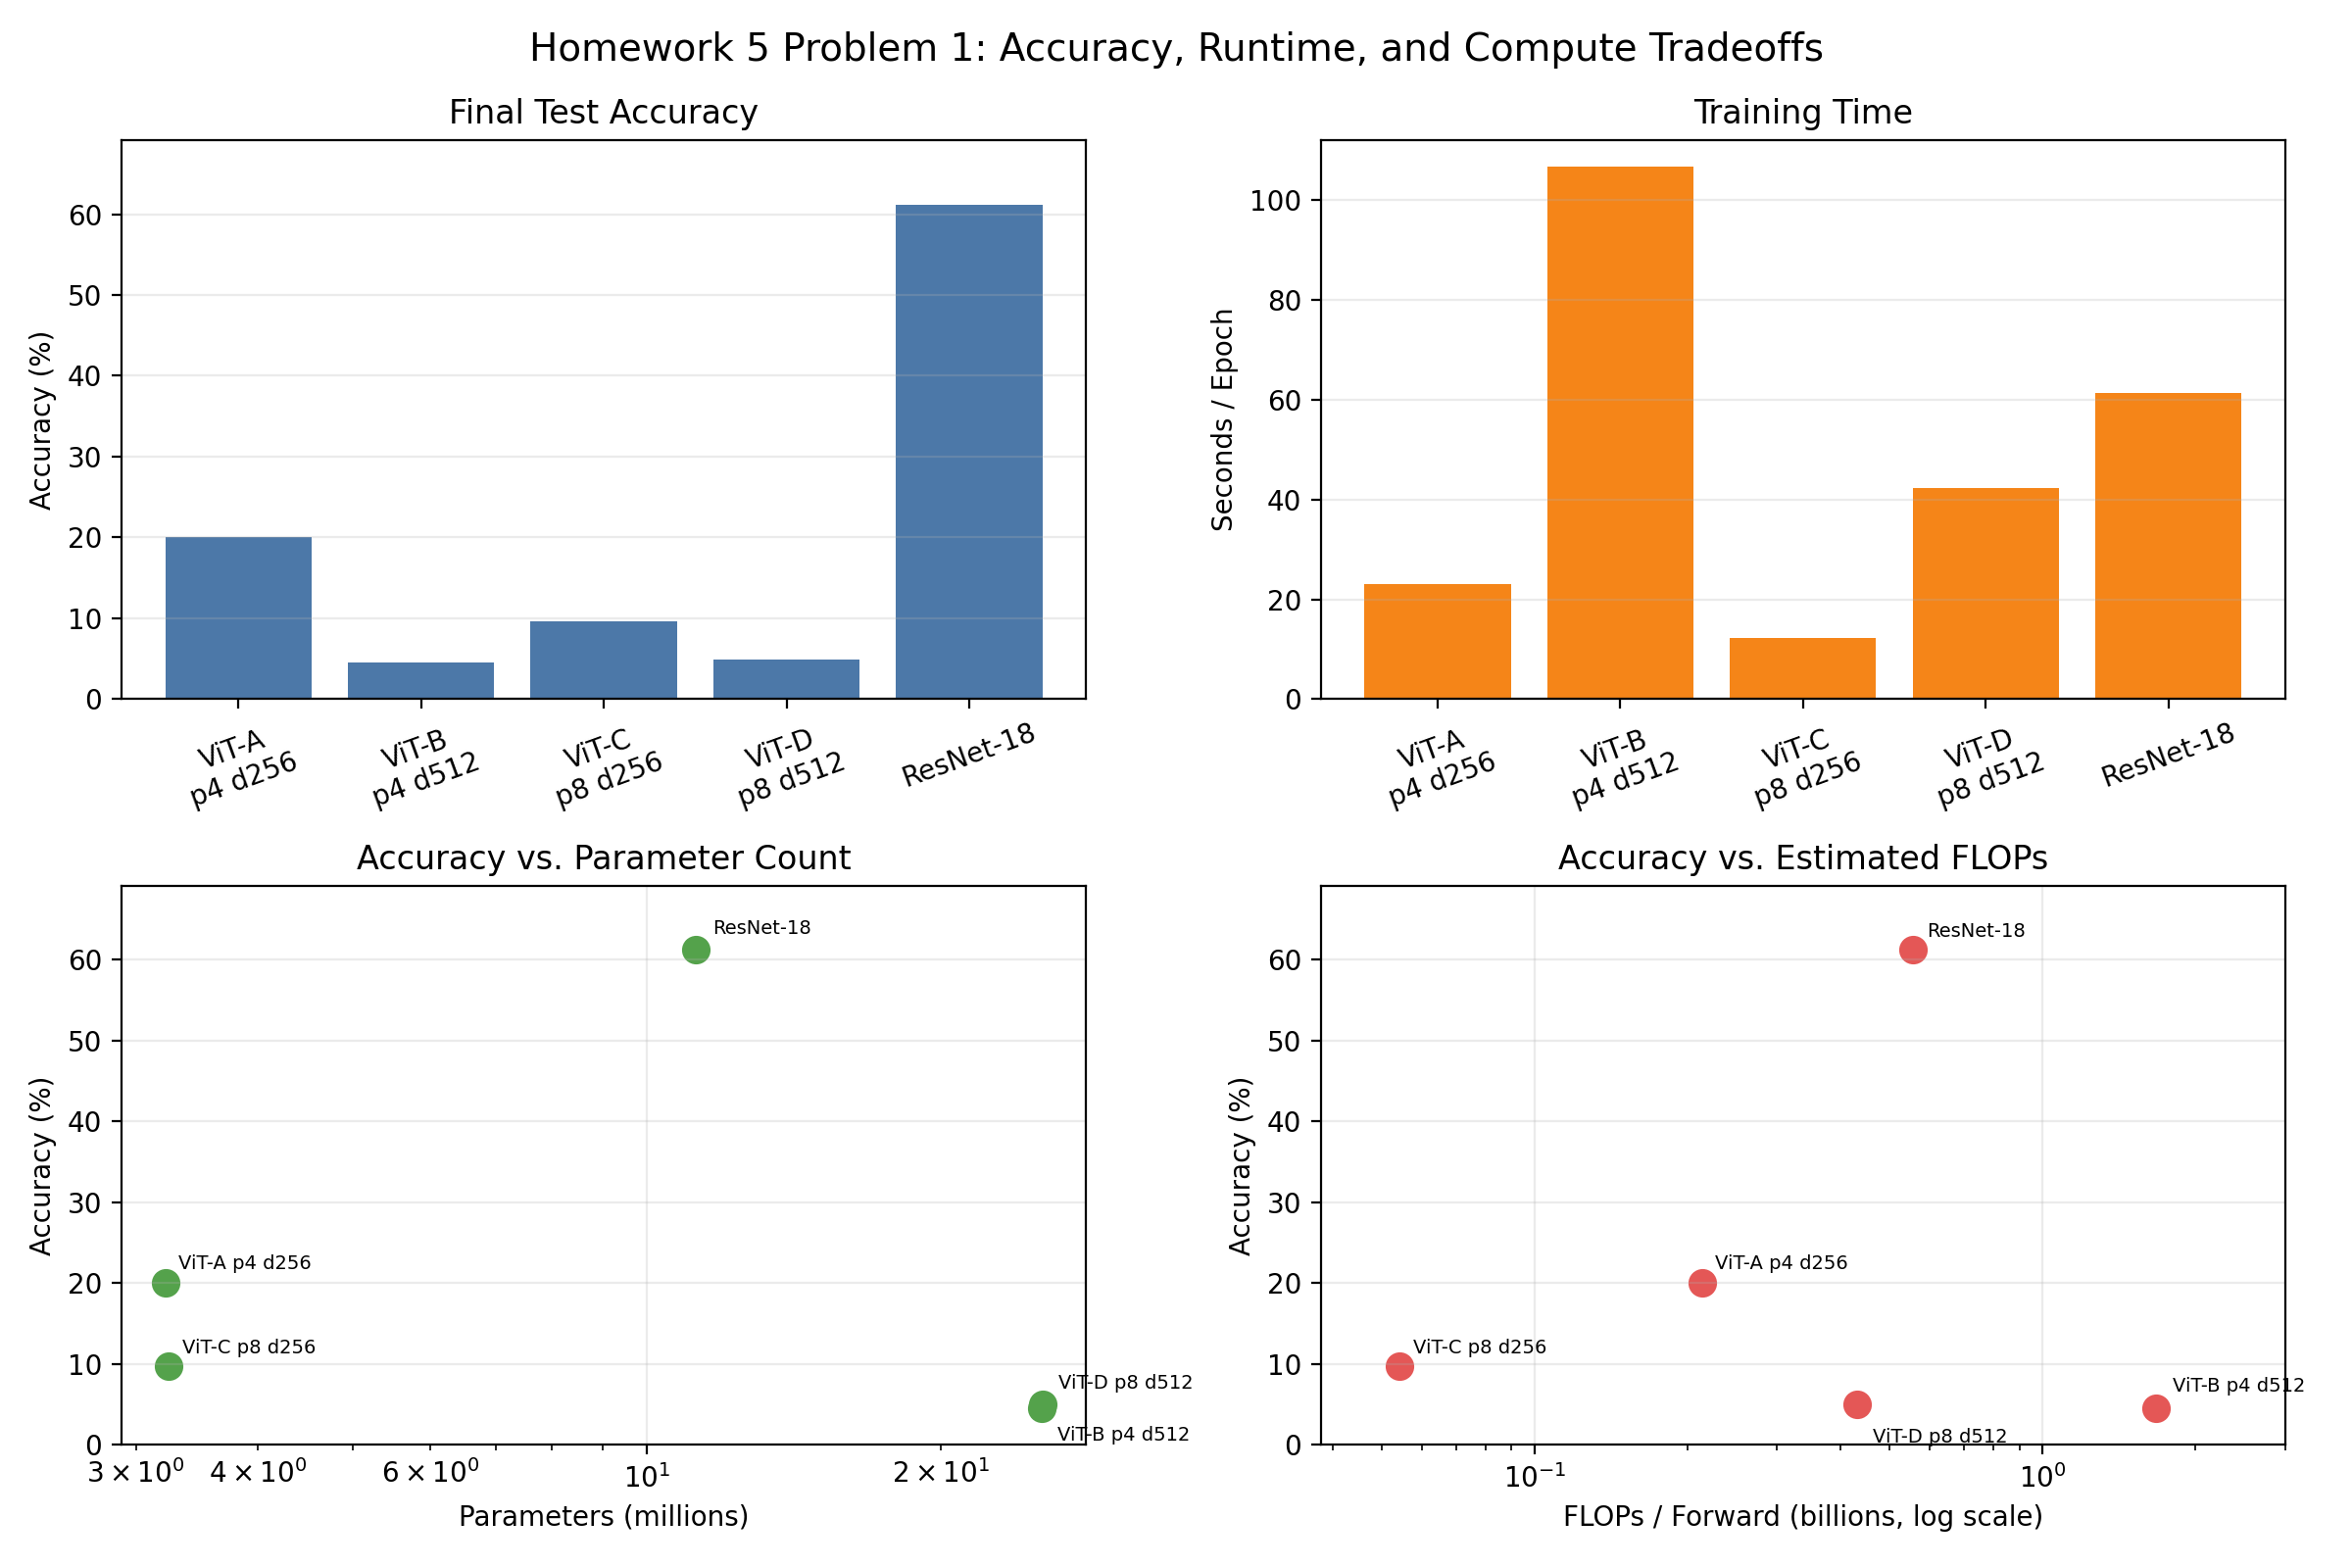

In [5]:
display(Markdown('### Loss and Accuracy Curves'))
display(Image(filename=str(plot_path)))
display(Markdown('### Accuracy, Runtime, and Compute Tradeoffs'))
display(Image(filename=str(tradeoff_path)))

## Interpretation

Among the ViT models, `vit_patch4_dim256_d4_h4` performs best at 20.01% test accuracy. `vit_patch8_dim256_d4_h4` is the next best ViT at 9.68% and has the lowest estimated FLOP count. Comparing those two rows isolates the patch-size effect: both use embedding dimension 256, depth 4, and 4 heads, but the 8 by 8 patch model uses far fewer tokens, lowers FLOPs from 2.13e8 to 5.41e7, and loses accuracy because it preserves less fine spatial detail.

Increasing model capacity did not improve the from-scratch ViTs under the short 10-epoch schedule. `vit_patch4_dim512_d8_h8` has many more parameters and FLOPs than `vit_patch4_dim256_d4_h4`, but its accuracy falls to 4.51%. The same pattern appears for the 8 by 8 patch pair. The training curves show that the larger ViTs stay near high cross-entropy loss and low accuracy, so their poor final results are consistent with under-optimization rather than a missing metric.

The ResNet-18 baseline is strongest overall at 61.20% test accuracy. Its train and validation losses decrease steadily across the plotted run, which verifies that the model is training properly. That is consistent with convolutional inductive bias helping on CIFAR-100, while from-scratch ViTs generally need longer schedules, stronger regularization, or pretraining.